In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
df = pd.read_csv("public_transport_delays.csv")

In [45]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [46]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [49]:
len(df)

2000

In [50]:
c = df.groupby('event_type')['event_type'].count()
c

event_type
Concert     203
Festival    221
Parade      105
Protest      86
Sports      212
Name: event_type, dtype: int64

In [51]:
df['event_type'].unique()

<StringArray>
[nan, 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [52]:
df['event_type'] = df['event_type'].fillna("NO Event")

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [54]:
pd.to_datetime(df['date'])
pd.to_datetime(df['time'])

C:\Users\praka\AppData\Local\Temp\ipykernel_21580\818874788.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


0      2026-04-03 05:00:00
1      2026-04-03 05:15:00
2      2026-04-03 05:30:00
3      2026-04-03 05:45:00
4      2026-04-03 06:00:00
               ...        
1995   2026-04-03 23:45:00
1996   2026-04-03 00:00:00
1997   2026-04-03 00:15:00
1998   2026-04-03 00:30:00
1999   2026-04-03 00:45:00
Name: time, Length: 2000, dtype: datetime64[us]

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [56]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [57]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NO Event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NO Event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NO Event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NO Event,500,46,0,0,6,Spring,1


In [58]:
df.isnull().sum()

trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [60]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [61]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [62]:
a = df.groupby('actual_arrival_delay_min')['actual_arrival_delay_min'].count()
a

actual_arrival_delay_min
-3     55
-2     61
-1     49
 0     55
 1     50
 2     57
 3     55
 4     62
 5     57
 6     58
 7     49
 8     45
 9     65
 10    76
 11    84
 12    64
 13    66
 14    67
 15    62
 16    69
 17    66
 18    66
 19    64
 20    51
 21    53
 22    58
 23    69
 24    75
 25    56
 26    61
 27    63
 28    65
 29    47
Name: actual_arrival_delay_min, dtype: int64

In [63]:
df['peak_hour'].head(15)

0     1
1     0
2     0
3     0
4     0
5     0
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    1
14    0
Name: peak_hour, dtype: int64

In [64]:
df['peak_hour'] = df['peak_hour'].replace({1: 'peak', 0: "non-Peak"})


In [65]:
df['peak_hour'].head()

0        peak
1    non-Peak
2    non-Peak
3    non-Peak
4    non-Peak
Name: peak_hour, dtype: object

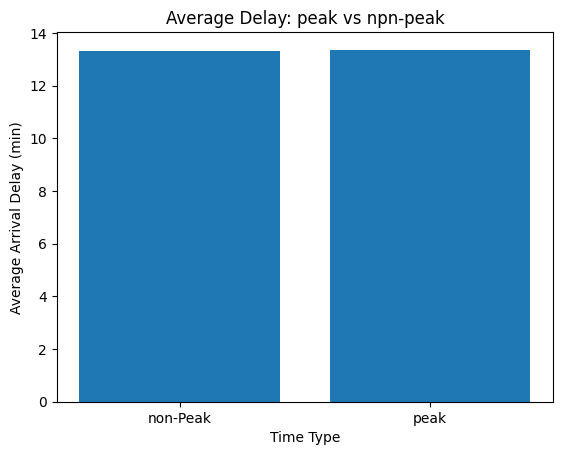

In [66]:
avg_delay = df.groupby('peak_hour')['actual_arrival_delay_min'].mean()
plt.bar(['non-Peak', 'peak'], avg_delay)
plt.xlabel('Time Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay: peak vs npn-peak')
plt.show()

In [67]:
df['traffic_level'] = pd.cut(df['traffic_congestion_index'],
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['low', 'medium', 'high', 'very_high', 'extreme'])

In [68]:
df['traffic_level'].head()

0      extreme
1         high
2    very_high
3      extreme
4         high
Name: traffic_level, dtype: category
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [69]:
avg_delay = df.groupby('traffic_level')['actual_arrival_delay_min'].mean()

<BarContainer object of 5 artists>

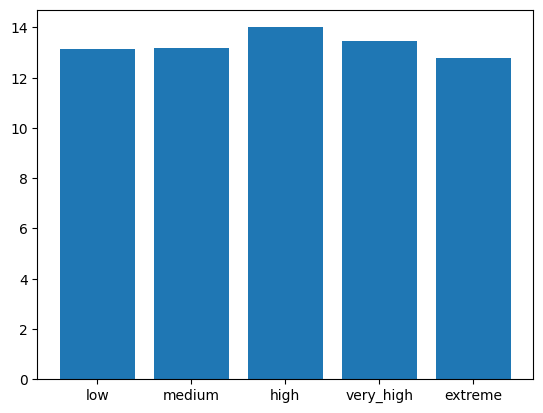

In [70]:
plt.bar(avg_delay.index, avg_delay.values) 

In [71]:
weather_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean()

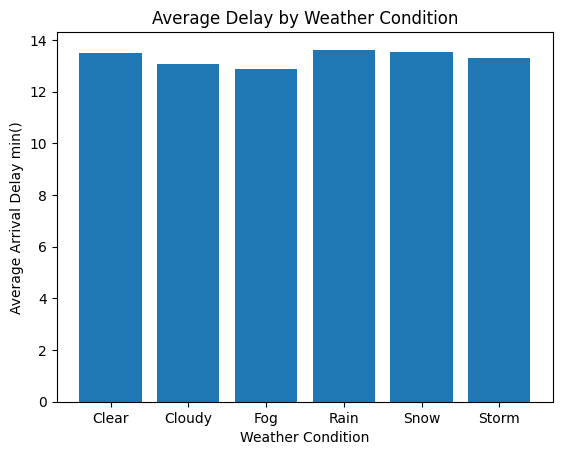

In [72]:
plt.bar(weather_delay.index, weather_delay.values)
plt.title('Average Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Arrival Delay min()')
plt.show()

In [73]:
event_analysis = df.groupby('event_type')['actual_arrival_delay_min'].mean()
event_analysis

event_type
Concert     12.832512
Festival    12.769231
NO Event    13.526002
Parade      13.619048
Protest     13.895349
Sports      12.820755
Name: actual_arrival_delay_min, dtype: float64

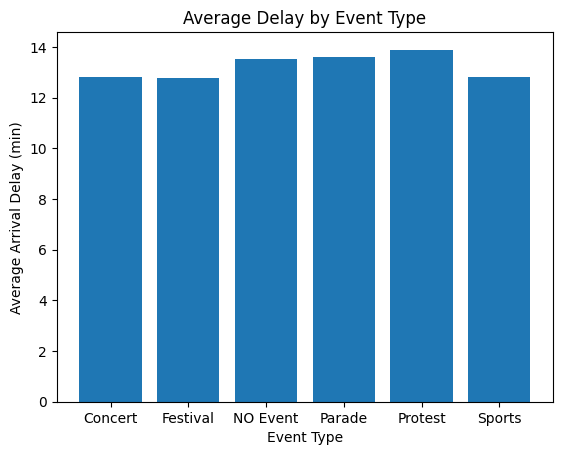

In [74]:
plt.bar(event_analysis.index, event_analysis.values)
plt.xlabel('Event Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Type')
plt.show()

In [75]:
df['event_attendance_est'].unique()

array([  500,     0, 50000,  2000, 10000])

In [76]:
df['attendas_level'] = df['event_attendance_est'].replace({
    0: 'no_event',
    500: 'small',
    2000: 'medium',
    10000: 'large',
    50000: 'huge'
})

In [77]:
attendance_analysis = df.groupby('attendas_level')['actual_arrival_delay_min'].mean()
attendance_analysis

attendas_level
huge        14.204762
large       13.754098
medium      14.404762
no_event    12.990132
small       12.790055
Name: actual_arrival_delay_min, dtype: float64

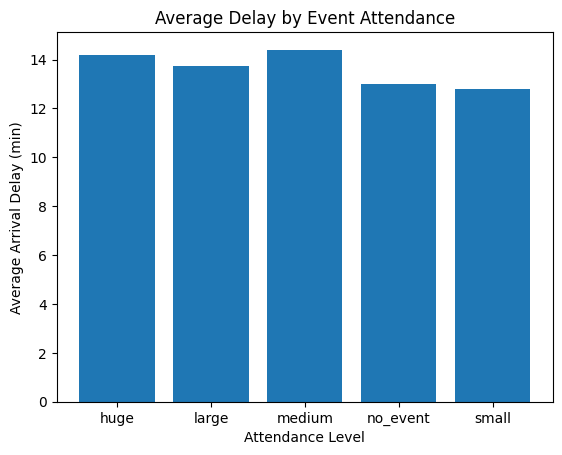

In [78]:

plt.bar(attendance_analysis.index, attendance_analysis.values)
plt.xlabel('Attendance Level')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Attendance')
plt.show()

In [80]:
pd.to_datetime(df['time'])
df

C:\Users\praka\AppData\Local\Temp\ipykernel_21580\1317857667.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,traffic_level,attendas_level
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,NO Event,500,81,0,peak,6,Winter,0,extreme,small
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,NO Event,0,53,0,non-Peak,6,Autumn,1,high,no_event
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,Sports,0,67,1,non-Peak,6,Autumn,0,very_high,no_event
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,NO Event,500,84,0,non-Peak,6,Winter,1,extreme,small
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,NO Event,500,46,0,non-Peak,6,Spring,1,high,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,NO Event,0,96,0,non-Peak,5,Winter,1,extreme,no_event
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,Festival,0,12,0,peak,6,Winter,1,low,no_event
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,NO Event,0,24,1,non-Peak,6,Summer,1,medium,no_event
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,NO Event,2000,23,0,non-Peak,6,Summer,1,medium,medium


In [84]:
df = df.drop(columns=['trip_id', 'route_id' ])

KeyError: "['T00000', 'T00001', 'T00002', 'T00003', 'T00004', 'T00005', 'T00006', 'T00007', 'T00008', 'T00009', 'T00010', 'T00011', 'T00012', 'T00013', 'T00014', 'T00015', 'T00016', 'T00017', 'T00018', 'T00019', 'T00020', 'T00021', 'T00022', 'T00023', 'T00024', 'T00025', 'T00026', 'T00027', 'T00028', 'T00029', 'T00030', 'T00031', 'T00032', 'T00033', 'T00034', 'T00035', 'T00036', 'T00037', 'T00038', 'T00039', 'T00040', 'T00041', 'T00042', 'T00043', 'T00044', 'T00045', 'T00046', 'T00047', 'T00048', 'T00049', 'T00050', 'T00051', 'T00052', 'T00053', 'T00054', 'T00055', 'T00056', 'T00057', 'T00058', 'T00059', 'T00060', 'T00061', 'T00062', 'T00063', 'T00064', 'T00065', 'T00066', 'T00067', 'T00068', 'T00069', 'T00070', 'T00071', 'T00072', 'T00073', 'T00074', 'T00075', 'T00076', 'T00077', 'T00078', 'T00079', 'T00080', 'T00081', 'T00082', 'T00083', 'T00084', 'T00085', 'T00086', 'T00087', 'T00088', 'T00089', 'T00090', 'T00091', 'T00092', 'T00093', 'T00094', 'T00095', 'T00096', 'T00097', 'T00098'